
データの入力方法は？
1:ベンチマーク(ft10)
2:ベンチマーク(ft06)
3:ベンチマーク(8x8 Custom)
4:ベンチマーク(20x5 Custom) [New]
5:手入力
6:乱数(機械の重複あり)
7:乱数(重複なし)
20x5 Customデータをロードしました。
計算時間制限: 100.0 秒


[No.1] Found at 2025-12-29 04:57:56 (JST) | Elapsed: 0.00 sec
       LB=974, Depth=100, Nodes=314

[No.2] Found at 2025-12-29 04:57:56 (JST) | Elapsed: 0.02 sec
       LB=972, Depth=100, Nodes=1130

[No.3] Found at 2025-12-29 04:57:56 (JST) | Elapsed: 0.34 sec
       LB=962, Depth=100, Nodes=21136

>>>> Optimal Solution Found: LB=962
Total Nodes: 21136
Total Elapsed Time: 0.34 sec
Start Time: 2025-12-29 04:57:56 (JST)
Finish Time: 2025-12-29 04:57:56 (JST)

Displaying Gantt Chart for the Best Solution found (LB=962).
Close the chart window to finish the program.


C:\Users\RJC238\AppData\Local\Temp\ipykernel_9456\236600274.py:304: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', self.n)


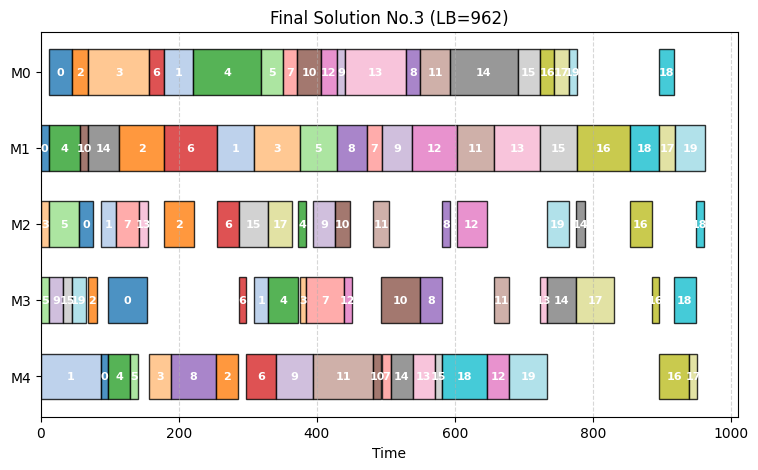

In [1]:
import sys
import time
import random
import os
import copy
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from datetime import datetime, timedelta, timezone

# --- 定数定義 ---
MAX_NUMBER_OF_MACHINES = 51
MAX_NUMBER_OF_JOBS = 201
MAX_NUMBER_OF_OPERATIONS = 101

# --- 日本標準時(JST)の定義 ---
JST = timezone(timedelta(hours=9), 'JST')

# --- データ構造クラス ---

class Machine:
    def __init__(self):
        self.assigned_job = -1
        self.assigned_time = 0
        self.loaded_time = 0

    def copy(self):
        m = Machine()
        m.assigned_job = self.assigned_job
        m.assigned_time = self.assigned_time
        m.loaded_time = self.loaded_time
        return m

class Job:
    def __init__(self):
        self.scheduled_steps = 0
        self.scheduled_time = 0
        self.remained_time = 0

    def copy(self):
        j = Job()
        j.scheduled_steps = self.scheduled_steps
        j.scheduled_time = self.scheduled_time
        j.remained_time = self.remained_time
        return j

class Node:
    def __init__(self):
        self.node_number = 0
        self.depth = 0
        self.number_of_unscheduled_jobs = 0
        self.machine = []  # List of Machine objects
        self.job = []      # List of Job objects
        self.evaluate_value = 0
        self.LB = 0
        self.terminal = 0
        self.parent = None
        self.next_node = None

    def clone(self):
        """
        手動ディープコピー（リンクは浅く、データは深く）
        """
        new_node = Node()
        new_node.node_number = self.node_number
        new_node.depth = self.depth
        new_node.number_of_unscheduled_jobs = self.number_of_unscheduled_jobs
        new_node.evaluate_value = self.evaluate_value
        new_node.LB = self.LB
        new_node.terminal = self.terminal

        # 配列の中身を新しいオブジェクトとしてコピー
        new_node.machine = [m.copy() for m in self.machine]
        new_node.job = [j.copy() for j in self.job]

        # 親への参照はそのままコピー
        new_node.parent = self.parent
        new_node.next_node = None

        return new_node

class MachinesData:
    def __init__(self):
        self.number_of_loaded_opes = 0
        self.total_time = 0
        self.assigned_job_number = []
        self.entry_time = []
        self.exit_time = []

class JobsData:
    def __init__(self):
        self.number_of_operations = 0
        self.processing_machine = []
        self.operation_time = []
        self.entry_time = []
        self.exit_time = []

# --- メインソルバークラス ---

class FlorianBABSolver:
    def __init__(self):
        self.m = 0
        self.n = 0
        self.x1 = 0
        self.initial_lb = 0
        self.num_of_developed_node = 0
        self.number_of_nodes = 0
        self.time_limit = 600.0 # デフォルト値

        self.mac_data = []
        self.job_data = []

        self.first_node_of_lb_chain = None

    def ensure_data_directories(self):
        os.makedirs("./data/GantChart", exist_ok=True)

    def sorting_first_node_of_lb_chain(self, new_node):
        if self.first_node_of_lb_chain is None:
            self.first_node_of_lb_chain = new_node
            new_node.next_node = None
        elif new_node.LB < self.first_node_of_lb_chain.LB:
            new_node.next_node = self.first_node_of_lb_chain
            self.first_node_of_lb_chain = new_node
        else:
            succeeding_node = self.first_node_of_lb_chain
            preceding_node = succeeding_node.next_node
            while (preceding_node is not None) and (new_node.LB >= preceding_node.LB):
                succeeding_node = preceding_node
                preceding_node = preceding_node.next_node

            succeeding_node.next_node = new_node
            new_node.next_node = preceding_node

    def sorting_first_node_of_lb_chain_2(self, new_node):
        if self.first_node_of_lb_chain is None:
            self.first_node_of_lb_chain = new_node
            new_node.next_node = None
        elif (new_node.LB < self.first_node_of_lb_chain.LB) or \
             ((new_node.LB == self.first_node_of_lb_chain.LB) and (new_node.evaluate_value < self.first_node_of_lb_chain.evaluate_value)):
            new_node.next_node = self.first_node_of_lb_chain
            self.first_node_of_lb_chain = new_node
        else:
            succeeding_node = self.first_node_of_lb_chain
            preceding_node = succeeding_node.next_node
            while (preceding_node is not None) and (new_node.LB >= preceding_node.LB):
                if (new_node.LB == preceding_node.LB) and (new_node.evaluate_value < preceding_node.evaluate_value):
                    break
                else:
                    succeeding_node = preceding_node
                    preceding_node = preceding_node.next_node

            succeeding_node.next_node = new_node
            new_node.next_node = preceding_node

    def calculate_lb_1(self, node):
        max_lb = 0
        for j in range(self.n):
            kk = node.job[j].scheduled_steps
            if kk < self.job_data[j].number_of_operations:
                k = self.job_data[j].processing_machine[kk]
                t = node.machine[k].assigned_time
                if t < node.job[j].scheduled_time:
                    t = node.job[j].scheduled_time
                lb_value = t + node.job[j].remained_time
            else:
                lb_value = node.job[j].scheduled_time

            if lb_value > max_lb:
                max_lb = lb_value

        for i in range(self.m):
            lb_value = node.machine[i].assigned_time + node.machine[i].loaded_time
            if lb_value > max_lb:
                max_lb = lb_value

        node.LB = max_lb
        if max_lb < self.initial_lb:
            node.LB = self.initial_lb

    def calculate_lb_2(self, node):
        max_lb = 0
        for j in range(self.n):
            kk = node.job[j].scheduled_steps
            if kk < self.job_data[j].number_of_operations:
                k = self.job_data[j].processing_machine[kk]
                tj = node.machine[k].assigned_time
                if tj < node.job[j].scheduled_time:
                    tj = node.job[j].scheduled_time
                lb_value = tj + node.job[j].remained_time
                if lb_value > max_lb:
                    max_lb = lb_value

        for i in range(self.m):
            flag = False
            min_tk = 2147483647
            for j in range(self.n):
                step = node.job[j].scheduled_steps
                if step < self.job_data[j].number_of_operations:
                    tk = 0
                    current_tk_for_calc = 0

                    for kk in range(step, self.job_data[j].number_of_operations):
                        k = self.job_data[j].processing_machine[kk]
                        if kk == step:
                            current_tk_for_calc = node.machine[k].assigned_time
                            if current_tk_for_calc < node.job[j].scheduled_time:
                                current_tk_for_calc = node.job[j].scheduled_time

                        if k == i:
                            flag = True
                            tk = current_tk_for_calc
                            break

                        current_tk_for_calc += self.job_data[j].operation_time[kk]

                    if flag and k == i:
                         if min_tk > tk:
                             min_tk = tk

            if flag:
                lb_value = min_tk + node.machine[i].loaded_time
            else:
                lb_value = node.machine[i].assigned_time

            if lb_value > max_lb:
                max_lb = lb_value

        node.LB = max_lb

    def calculate_loaded_opes_of_each_machine(self):
        for i in range(self.m):
            self.mac_data[i].total_time = 0
            self.mac_data[i].number_of_loaded_opes = 0

        for j in range(self.n):
            for kk in range(self.job_data[j].number_of_operations):
                k = self.job_data[j].processing_machine[kk]
                self.mac_data[k].total_time += self.job_data[j].operation_time[kk]
                self.mac_data[k].number_of_loaded_opes += 1

    def make_new_node_and_put_into_lb_chain(self, parent_node, mc, conflict_job_indices):
        for select_j in conflict_job_indices:
            if select_j == -1:
                continue

            new_node = parent_node.clone()

            self.number_of_nodes += 1
            self.num_of_developed_node += 1

            new_node.node_number = self.num_of_developed_node
            new_node.depth = parent_node.depth + 1
            new_node.parent = parent_node

            kk = new_node.job[select_j].scheduled_steps
            t = new_node.machine[mc].assigned_time

            if t < new_node.job[select_j].scheduled_time:
                t = new_node.job[select_j].scheduled_time

            eval_t = t
            t += self.job_data[select_j].operation_time[kk]

            new_node.machine[mc].assigned_time = t
            new_node.job[select_j].scheduled_time = t

            for i in range(self.m):
                new_node.machine[i].assigned_job = -1
            new_node.machine[mc].assigned_job = select_j

            new_node.job[select_j].scheduled_steps = kk + 1
            op_time = self.job_data[select_j].operation_time[kk]
            new_node.machine[mc].loaded_time -= op_time

            remain_t = new_node.job[select_j].remained_time
            remain_opes = self.job_data[select_j].number_of_operations - kk
            new_node.job[select_j].remained_time -= op_time

            if new_node.job[select_j].scheduled_steps == self.job_data[select_j].number_of_operations:
                new_node.number_of_unscheduled_jobs -= 1

            if new_node.number_of_unscheduled_jobs == 0:
                new_node.terminal = 1

            v = remain_t * remain_opes

            if self.x1 == 0:
                self.calculate_lb_1(new_node)
                self.sorting_first_node_of_lb_chain(new_node)
            elif self.x1 == 1:
                new_node.evaluate_value = eval_t
                self.calculate_lb_1(new_node)
                self.sorting_first_node_of_lb_chain_2(new_node)
            elif self.x1 == 2:
                new_node.evaluate_value = -v
                self.calculate_lb_1(new_node)
                self.sorting_first_node_of_lb_chain_2(new_node)

    def draw_gantt_chart(self, lb_value, count):
        """ガントチャートを画面（コンソール/ウィンドウ）に表示する"""
        if self.m == 0: return

        # カラーマップの準備
        cmap = cm.get_cmap('tab20', self.n)
        colors = [cmap(i % 20) for i in range(self.n)] # 20色以上に対応

        fig, ax = plt.subplots(figsize=(9, 5)) # サイズを少し大きく

        # Y軸: 機械, X軸: 時間
        for i in range(self.m):
            num_ops = self.mac_data[i].number_of_loaded_opes
            for k in range(num_ops):
                job_idx = self.mac_data[i].assigned_job_number[k]
                start_t = self.mac_data[i].entry_time[k]
                end_t = self.mac_data[i].exit_time[k]
                duration = end_t - start_t

                # バーの描画
                ax.barh(y=i, width=duration, left=start_t,height=0.6,
                        color=colors[job_idx % len(colors)], edgecolor='black', align='center', alpha=0.8)

                # ジョブ番号のテキスト表示（バーの中央）
                # 20x5だと混み合うのでフォントサイズを調整
                ax.text(start_t + duration/2, i, f"{job_idx}",
                        ha='center', va='center', color='white', fontweight='bold', fontsize=8)

        # グラフの体裁を整える
        ax.set_yticks(range(self.m))
        ax.set_yticklabels([f"M{i}" for i in range(self.m)])
        ax.set_xlabel("Time")
        ax.set_title(f"Final Solution No.{count} (LB={lb_value})")
        ax.invert_yaxis()
        ax.grid(axis='x', linestyle='--', alpha=0.5)

        print(f"\nDisplaying Gantt Chart for the Best Solution found (LB={lb_value}).")
        print("Close the chart window to finish the program.")
        plt.show()

    def display_feasible_schedule(self, new_feasible_node, sol_count, draw=False):
        """
        実行可能スケジュールのデータ化、CSV出力、および必要に応じたガントチャート描画
        """
        mc_que = [0] * self.m
        assign_que = [0] * self.n

        for i in range(self.m):
            count = self.mac_data[i].number_of_loaded_opes
            self.mac_data[i].assigned_job_number = [0] * count
            self.mac_data[i].entry_time = [0] * count
            self.mac_data[i].exit_time = [0] * count
            mc_que[i] = count - 1

        for j in range(self.n):
            count = self.job_data[j].number_of_operations
            self.job_data[j].entry_time = [0] * count
            self.job_data[j].exit_time = [0] * count
            assign_que[j] = count - 1

        the_node_1 = new_feasible_node

        while the_node_1.parent is not None:
            mc = -1
            jj = -1
            for i in range(self.m):
                if the_node_1.machine[i].assigned_job != -1:
                    mc = i
                    jj = the_node_1.machine[i].assigned_job
                    break

            if mc != -1 and jj != -1:
                ope_idx = assign_que[jj]
                op_time = self.job_data[jj].operation_time[ope_idx]

                t_m = the_node_1.machine[mc].assigned_time - op_time
                t_j = the_node_1.job[jj].scheduled_time - op_time

                mac_idx = mc_que[mc]
                self.mac_data[mc].assigned_job_number[mac_idx] = jj
                self.mac_data[mc].entry_time[mac_idx] = t_m
                self.mac_data[mc].exit_time[mac_idx] = the_node_1.machine[mc].assigned_time

                self.job_data[jj].entry_time[ope_idx] = t_j
                self.job_data[jj].exit_time[ope_idx] = the_node_1.job[jj].scheduled_time

                mc_que[mc] -= 1
                assign_que[jj] -= 1

            the_node_1 = the_node_1.parent

        try:
            with open("./data/GantChart/MC_Gant.csv", "w") as f:
                f.write("MC_No,Ope_No,JB_No,ST_T,ED_T\n")
                for i in range(self.m):
                    for kk in range(self.mac_data[i].number_of_loaded_opes):
                        f.write(f"{i},{kk},{self.mac_data[i].assigned_job_number[kk]},"
                                f"{self.mac_data[i].entry_time[kk]},{self.mac_data[i].exit_time[kk]}\n")

            with open("./data/GantChart/JB_Gant.csv", "w") as f:
                f.write("JB_No,Ope_No,MC_No,ST_T,ED_T\n")
                for j in range(self.n):
                    for kk in range(self.job_data[j].number_of_operations):
                        f.write(f"{j},{kk},{self.job_data[j].processing_machine[kk]},"
                                f"{self.job_data[j].entry_time[kk]},{self.job_data[j].exit_time[kk]}\n")
        except IOError as e:
            print(f"File write error: {e}")

        if draw:
            self.draw_gantt_chart(new_feasible_node.LB, sol_count)

    # --- 入力メソッド ---

    def benchmark_ft10(self):
        """Fisher and Thompson 10x10 (ft10) Benchmark Data"""
        self.m = 10
        self.n = 10

        self.mac_data = [MachinesData() for _ in range(self.m)]
        self.job_data = [JobsData() for _ in range(self.n)]

        # ft10 Data: (Machine, Time)
        ft10_raw = [
            [(0, 29), (1, 78), (2, 9), (3, 36), (4, 49), (5, 11), (6, 62), (7, 56), (8, 44), (9, 21)],
            [(0, 43), (2, 90), (4, 75), (9, 11), (3, 69), (1, 28), (6, 46), (5, 46), (7, 72), (8, 30)],
            [(1, 91), (0, 85), (3, 39), (2, 74), (8, 90), (5, 10), (7, 12), (6, 89), (9, 45), (4, 33)],
            [(1, 81), (2, 95), (0, 71), (4, 99), (6, 9), (8, 52), (7, 85), (3, 98), (9, 22), (5, 43)],
            [(2, 14), (0, 6), (1, 22), (5, 61), (3, 26), (4, 69), (8, 21), (7, 49), (9, 72), (6, 53)],
            [(2, 84), (1, 2), (5, 52), (3, 95), (8, 48), (9, 72), (0, 47), (6, 65), (4, 6), (7, 25)],
            [(1, 46), (0, 37), (3, 61), (2, 13), (6, 32), (5, 21), (9, 32), (8, 89), (7, 30), (4, 55)],
            [(2, 31), (0, 86), (1, 46), (5, 74), (4, 32), (6, 88), (8, 19), (9, 48), (7, 36), (3, 79)],
            [(0, 76), (1, 69), (3, 76), (5, 51), (2, 85), (9, 11), (6, 40), (7, 89), (4, 26), (8, 74)],
            [(1, 85), (0, 13), (2, 61), (6, 7), (8, 64), (9, 76), (5, 47), (3, 52), (4, 90), (7, 45)]
        ]

        for j in range(self.n):
            self.job_data[j].number_of_operations = self.m
            self.job_data[j].processing_machine = [op[0] for op in ft10_raw[j]]
            self.job_data[j].operation_time = [op[1] for op in ft10_raw[j]]

        print("ft10データをロードしました。")
        self.write_input_to_file()

    def benchmark_ft06(self):
        """Fisher and Thompson 6x6 (ft06) Benchmark Data"""
        self.m = 6
        self.n = 6

        self.mac_data = [MachinesData() for _ in range(self.m)]
        self.job_data = [JobsData() for _ in range(self.n)]

        # ft06 Data: (Machine, Time)
        ft06_raw = [
            [(2, 1), (0, 3), (1, 6), (3, 7), (5, 3), (4, 6)],
            [(1, 8), (2, 5), (4, 10), (5, 10), (0, 10), (3, 4)],
            [(2, 5), (3, 4), (5, 8), (0, 9), (1, 1), (4, 7)],
            [(1, 5), (0, 5), (2, 5), (3, 3), (4, 8), (5, 9)],
            [(2, 9), (1, 3), (4, 5), (5, 4), (0, 3), (3, 1)],
            [(1, 3), (3, 3), (5, 9), (0, 10), (4, 4), (2, 1)]
        ]

        for j in range(self.n):
            self.job_data[j].number_of_operations = self.m
            self.job_data[j].processing_machine = [op[0] for op in ft06_raw[j]]
            self.job_data[j].operation_time = [op[1] for op in ft06_raw[j]]

        print("ft06データをロードしました。")
        self.write_input_to_file()

    def benchmark_8x8(self):
        """Custom 8x8 Benchmark Data"""
        self.m = 8
        self.n = 8

        self.mac_data = [MachinesData() for _ in range(self.m)]
        self.job_data = [JobsData() for _ in range(self.n)]

        # 8x8 Custom Data
        raw_8x8 = [
            [(0, 5), (1, 12), (2, 8), (3, 20), (4, 15), (5, 6), (6, 9), (7, 10)],
            [(3, 10), (2, 15), (0, 8), (1, 22), (5, 18), (4, 12), (7, 7), (6, 14)],
            [(2, 20), (5, 8), (1, 10), (0, 15), (4, 7), (3, 9), (6, 11), (7, 13)],
            [(1, 14), (0, 6), (3, 12), (2, 18), (6, 10), (5, 5), (7, 16), (4, 9)],
            [(4, 10), (6, 12), (7, 8), (1, 15), (0, 20), (2, 7), (3, 11), (5, 14)],
            [(5, 8), (4, 18), (6, 5), (7, 12), (1, 9), (0, 14), (2, 10), (3, 15)],
            [(6, 15), (7, 10), (5, 12), (4, 8), (2, 20), (3, 6), (1, 18), (0, 7)],
            [(7, 9), (3, 14), (4, 16), (6, 11), (5, 8), (2, 13), (0, 10), (1, 12)]
        ]

        for j in range(self.n):
            self.job_data[j].number_of_operations = self.m
            self.job_data[j].processing_machine = [op[0] for op in raw_8x8[j]]
            self.job_data[j].operation_time = [op[1] for op in raw_8x8[j]]

        print("8x8 Customデータをロードしました。")
        self.write_input_to_file()

    # ★ 追加した20x5カスタム問題データ
    def benchmark_20x5(self):
        """Custom 20x5 Benchmark Data (Inspired by la11/ft20 dimensions)"""
        self.m = 5
        self.n = 20

        self.mac_data = [MachinesData() for _ in range(self.m)]
        self.job_data = [JobsData() for _ in range(self.n)]

        # 20x5 Custom Data (Machine, Time)
        raw_20x5 = [
            [(1, 12), (0, 34), (2, 21), (4, 11), (3, 56)], # Job 0
            [(4, 87), (2, 22), (0, 43), (1, 54), (3, 21)],
            [(0, 23), (3, 12), (1, 65), (2, 43), (4, 32)],
            [(2, 12), (0, 88), (4, 32), (1, 66), (3, 10)],
            [(1, 45), (4, 32), (0, 98), (3, 43), (2, 12)],
            [(3, 12), (2, 43), (4, 11), (0, 32), (1, 54)],
            [(0, 21), (1, 76), (2, 32), (3, 11), (4, 43)],
            [(2, 34), (0, 21), (3, 54), (1, 23), (4, 12)],
            [(4, 65), (1, 43), (0, 21), (3, 32), (2, 11)],
            [(3, 21), (4, 54), (2, 32), (0, 12), (1, 43)],
            [(1, 12), (0, 34), (2, 21), (4, 11), (3, 56)], # Job 10 (Job0と同じパターン)
            [(4, 87), (2, 22), (0, 43), (1, 54), (3, 21)],
            [(0, 23), (3, 12), (1, 65), (2, 43), (4, 32)],
            [(2, 12), (0, 88), (4, 32), (1, 66), (3, 10)],
            [(1, 45), (4, 32), (0, 98), (3, 43), (2, 12)],
            [(3, 12), (2, 43), (4, 11), (0, 32), (1, 54)],
            [(0, 21), (1, 76), (2, 32), (3, 11), (4, 43)],
            [(2, 34), (0, 21), (3, 54), (1, 23), (4, 12)],
            [(4, 65), (1, 43), (0, 21), (3, 32), (2, 11)],
            [(3, 21), (4, 54), (2, 32), (0, 12), (1, 43)]
        ]

        for j in range(self.n):
            self.job_data[j].number_of_operations = self.m
            self.job_data[j].processing_machine = [op[0] for op in raw_20x5[j]]
            self.job_data[j].operation_time = [op[1] for op in raw_20x5[j]]

        print("20x5 Customデータをロードしました。")
        self.write_input_to_file()

    def manual_input(self):
        for j in range(self.n):
            val = input(f"\nジョブ[{j}]の作業数は？ ")
            self.job_data[j].number_of_operations = int(val)

        for j in range(self.n):
            self.job_data[j].processing_machine = [0] * self.job_data[j].number_of_operations
            self.job_data[j].operation_time = [0] * self.job_data[j].number_of_operations
            for kk in range(self.job_data[j].number_of_operations):
                mc = int(input(f"  \nジョブ[{j}]の作業番号[{kk}]の機械番号M="))
                self.job_data[j].processing_machine[kk] = mc - 1
                t = int(input(f"  \nジョブ[{j}]の作業番号[{kk}]の作業時間T="))
                self.job_data[j].operation_time[kk] = t

    def random_input(self):
        rnd_seed = int(input("乱数シードを入力して下さい。="))
        random.seed(rnd_seed)
        ope = self.m * 2
        for j in range(self.n):
            k = 1 if self.m == 1 else random.randint(1, ope)
            self.job_data[j].number_of_operations = k
            self.job_data[j].processing_machine = [0] * k
            self.job_data[j].operation_time = [0] * k

        for j in range(self.n):
            mc = 0 if self.m == 1 else random.randint(0, self.m - 1)
            for kk in range(self.job_data[j].number_of_operations):
                pre_mc = mc
                loop = True
                if self.m != 1:
                    while loop:
                        mc = random.randint(0, self.m - 1)
                        if mc != pre_mc: loop = False
                self.job_data[j].processing_machine[kk] = mc
                self.job_data[j].operation_time[kk] = random.randint(1, 20)
        self.write_input_to_file()

    def random_input_2(self):
        rnd_seed = int(input("乱数シードを入力して下さい。="))
        random.seed(rnd_seed)
        for j in range(self.n):
            self.job_data[j].number_of_operations = self.m
            mc_list = list(range(self.m))
            if self.m > 1: random.shuffle(mc_list)
            self.job_data[j].processing_machine = mc_list
            self.job_data[j].operation_time = [random.randint(1, 9) for _ in range(self.m)]
        self.write_input_to_file()

    def write_input_to_file(self):
        fname = f"./data/data_{self.n}_{self.m}.csv"
        try:
            with open(fname, "w") as f:
                for j in range(self.n):
                    f.write(f"{j},")
                    for kk in range(self.job_data[j].number_of_operations):
                        f.write(f"{self.job_data[j].processing_machine[kk]},{self.job_data[j].operation_time[kk]},")
                    f.write("\n")
        except IOError as e:
            print(f"File write error: {e}")

    def input_data(self):
        print("\nデータの入力方法は？")
        print("1:ベンチマーク(ft10)")
        print("2:ベンチマーク(ft06)")
        print("3:ベンチマーク(8x8 Custom)")
        print("4:ベンチマーク(20x5 Custom) [New]")
        print("5:手入力")
        print("6:乱数(機械の重複あり)")
        print("7:乱数(重複なし)")

        try:
            x2 = int(input("選択: "))
        except ValueError:
            x2 = 5 # default to manual

        if x2 == 1:
            self.benchmark_ft10()
        elif x2 == 2:
            self.benchmark_ft06()
        elif x2 == 3:
            self.benchmark_8x8()
        elif x2 == 4:
            self.benchmark_20x5()
        else:
            self.m = int(input("   \n機械の台数は？ "))
            self.n = int(input("   \nジョブ数は？ "))
            self.mac_data = [MachinesData() for _ in range(self.m)]
            self.job_data = [JobsData() for _ in range(self.n)]

            if x2 == 5: self.manual_input()
            elif x2 == 6: self.random_input()
            elif x2 == 7: self.random_input_2()

        # LB Method Selection
        self.x1 = int(input("\nLB値の算出方法は？ ( 通常: 0、... ) ＝"))

        try:
            limit_in = input("\n計算時間の制限(秒)を入力してください (デフォルト=600): ")
            if limit_in.strip() == "":
                self.time_limit = 600.0
            else:
                self.time_limit = float(limit_in)
        except ValueError:
            print("無効な入力です。600秒に設定します。")
            self.time_limit = 600.0
        print(f"計算時間制限: {self.time_limit} 秒\n")

    # --- 実行ロジック ---

    def run(self):
        self.ensure_data_directories()

        feasible_nodes_lb = 2147483647

        self.input_data()

        start_time = time.time()
        start_time_str = datetime.now(JST).strftime("%Y-%m-%d %H:%M:%S")
        count = 0
        self.number_of_nodes = 0
        self.num_of_developed_node = 0

        # Root Node
        root_node = Node()
        self.number_of_nodes += 1
        self.num_of_developed_node += 1
        root_node.number_of_unscheduled_jobs = self.n
        root_node.machine = [Machine() for _ in range(self.m)]

        self.calculate_loaded_opes_of_each_machine()
        for i in range(self.m):
            root_node.machine[i].loaded_time = self.mac_data[i].total_time

        root_node.job = [Job() for _ in range(self.n)]
        for j in range(self.n):
            root_node.job[j].remained_time = sum(self.job_data[j].operation_time)

        self.calculate_lb_2(root_node)
        self.sorting_first_node_of_lb_chain(root_node)

        self.initial_lb = self.first_node_of_lb_chain.LB
        the_node = self.first_node_of_lb_chain

        new_feasible_node = None
        flag = False
        loop = True

        while the_node is not None and not flag:
            # Branching
            while True:
                min_t = 2147483647
                conflict_mc_num = 0

                # Check conflicts
                for j in range(self.n):
                    kk = the_node.job[j].scheduled_steps
                    if kk < self.job_data[j].number_of_operations:
                        k = self.job_data[j].processing_machine[kk]
                        t = the_node.machine[k].assigned_time
                        if t < the_node.job[j].scheduled_time:
                            t = the_node.job[j].scheduled_time
                        t += self.job_data[j].operation_time[kk]
                        if min_t > t:
                            min_t = t
                            conflict_mc_num = k

                conflict = [-1] * self.n
                for j in range(self.n):
                    kk = the_node.job[j].scheduled_steps
                    if kk < self.job_data[j].number_of_operations:
                        k = self.job_data[j].processing_machine[kk]
                        t = the_node.machine[k].assigned_time
                        if t < the_node.job[j].scheduled_time:
                            t = the_node.job[j].scheduled_time
                        if (k == conflict_mc_num) and (t < min_t):
                            conflict[j] = j

                self.first_node_of_lb_chain = None
                self.make_new_node_and_put_into_lb_chain(the_node, conflict_mc_num, conflict)

                the_node = self.first_node_of_lb_chain

                if (time.time() - start_time) >= self.time_limit:
                    flag = True
                    break

                if the_node is None: break
                if (the_node.terminal == 1) or (the_node.LB >= feasible_nodes_lb): break

            # Solution check
            if (the_node is not None) and (the_node.terminal == 1) and (the_node.LB < feasible_nodes_lb):
                new_feasible_node = the_node.clone()
                feasible_nodes_lb = new_feasible_node.LB
                count += 1
                self.display_feasible_schedule(new_feasible_node, count, draw=False)

                current_time = time.time()
                current_time_str = datetime.now(JST).strftime("%Y-%m-%d %H:%M:%S")
                elapsed = current_time - start_time
                print(f"\n[No.{count}] Found at {current_time_str} (JST) | Elapsed: {elapsed:.2f} sec")
                print(f"       LB={new_feasible_node.LB}, Depth={new_feasible_node.depth}, Nodes={self.num_of_developed_node}")

                if (time.time() - start_time) >= self.time_limit: flag = True; break

            if not flag: loop = True
            else: break

            # Backtracking
            while loop:
                parent_node = the_node.parent if the_node else None
                next_node_cand = the_node.next_node if the_node else None

                if the_node: self.number_of_nodes -= 1
                the_node = next_node_cand

                while (the_node is not None) and (the_node.LB >= feasible_nodes_lb):
                    temp = the_node.next_node
                    self.number_of_nodes -= 1
                    the_node = temp

                if (time.time() - start_time) >= self.time_limit: flag = True; break

                if the_node is not None:
                    loop = False
                else:
                    if parent_node is None:
                        the_node = None
                        loop = False
                    else:
                        the_node = parent_node

        end_time = time.time()
        total_time = end_time - start_time
        finish_time_str = datetime.now(JST).strftime("%Y-%m-%d %H:%M:%S")

        if not flag and new_feasible_node:
            print(f"\n>>>> Optimal Solution Found: LB={new_feasible_node.LB}")
        elif new_feasible_node:
            print(f"\n>>>> Best Solution (Time Limit): LB={new_feasible_node.LB}")
        else:
            print("\nNo solution found.")

        print(f"Total Nodes: {self.num_of_developed_node}")
        print(f"Total Elapsed Time: {total_time:.2f} sec")
        print(f"Start Time: {start_time_str} (JST)")
        print(f"Finish Time: {finish_time_str} (JST)")

        if new_feasible_node:
             self.display_feasible_schedule(new_feasible_node, count, draw=True)

if __name__ == "__main__":
    solver = FlorianBABSolver()
    solver.run()
